First we add all of the modules we are going to use. Google Colab does not come with Bambi pre-installed, but we can install it with pip.

In [39]:
!pip install bambi
import pymc as pm
import pandas as pd
import arviz as az
import bambi as bmb
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

Let's load and visualize our data.

In [40]:
data_url = "https://raw.githubusercontent.com/NAU-SHERC-ResearchCapacityCore/Python-Coding-Series-1/refs/heads/main/data/iris.csv"
data = pd.read_csv(data_url)
print(data.head())

   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width Species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


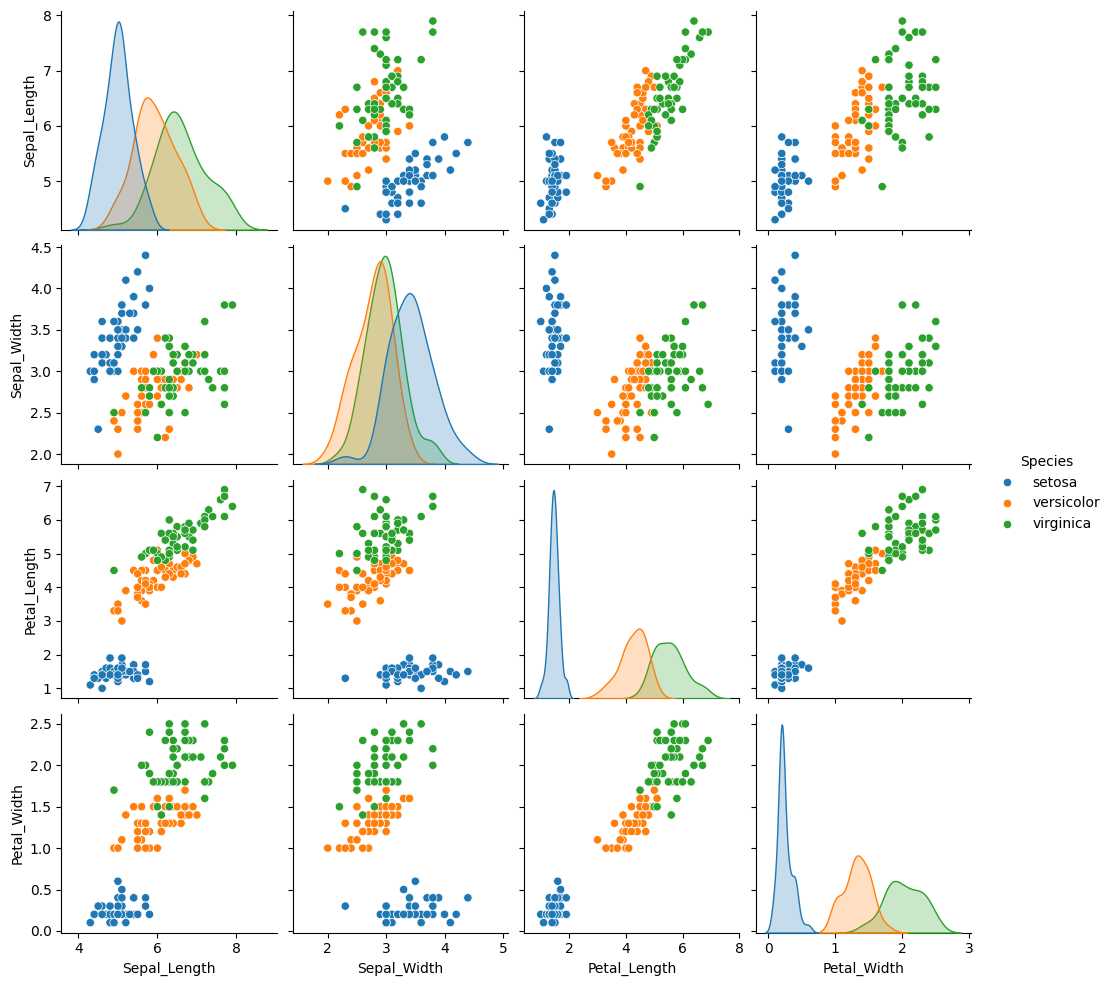

In [41]:
sns.pairplot(data, hue="Species")
plt.show()

Here we build a model in Bambi using an R-style formula.

Consider modifying the formula to add `"Species"` as a categorical variable.
- Adding `"Petal_Width ~ Sepal_Width + C(Species)"` will use a separate intercept for each species.
- Adding `"Petal_Width ~ Sepal_Width*C(Species)"`, using the `"*"` notation, will add all interaction terms. This means each species has its own intercept **and** its own slope.

In [42]:
formula = "Petal_Width ~ Sepal_Width"
model = bmb.Model(formula, data=data)
result = model.fit()

Output()

Let's plot the trace plot.

/usr/local/lib/python3.12/dist-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(


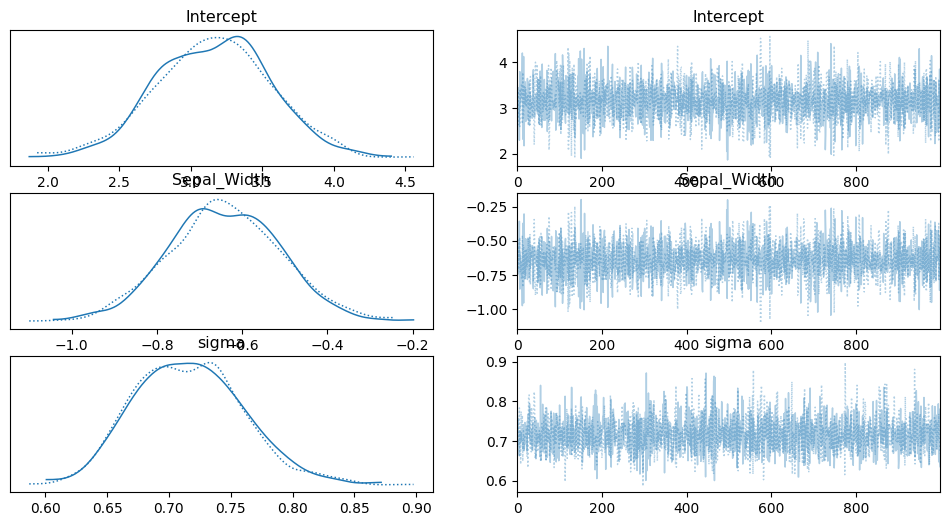

In [43]:
az.plot_trace(result, var_names="~mu")
plt.show()

Here is a visualization of the model structure.

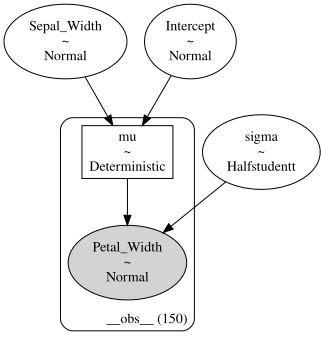

In [44]:
model.graph()

Here is a summary of the fit.

In [45]:
az.summary(result)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,3.162,0.417,2.403,4.004,0.007,0.010,3429.0,1626.0,1.0
Sepal_Width,-0.642,0.135,-0.899,-0.393,0.002,0.003,3440.0,1767.0,1.0
sigma,0.717,0.045,0.638,0.803,0.001,0.001,2949.0,1492.0,1.0


Here is the posterior predictive distribution. This shows us how well our model output matches the distribution of the data.

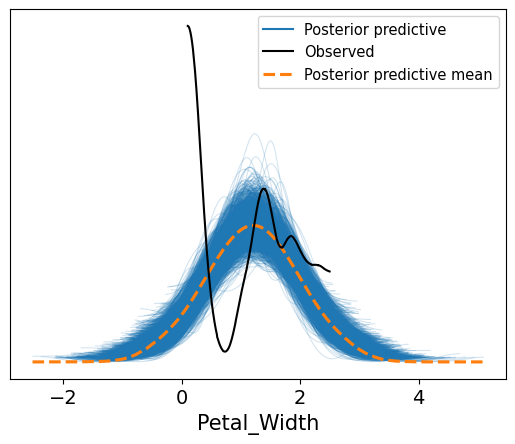

In [46]:
model.predict(result, kind='response')
az.plot_ppc(result)
plt.show()